In [1]:
# Step 1: Import pandas
import pandas as pd

# Step 2: Load TSV dataset
tsv_path = "../dataset/dataset.tsv"  # adjust if your path is different
df = pd.read_csv(tsv_path, sep="\t")

# Step 3: Check first few rows
df.head()


,page_id,text,label,Pattern Category
0,1012,FLASH SALE | LIMITED TIME ONLY Shop Now,1,Urgency
1,158,Pillowcases & Shams,0,Not Dark Pattern
2,108,Write a review,0,Not Dark Pattern
3,1425,"To start your return, simply click on the foll...",0,Not Dark Pattern
4,1658,newsletter signup (privacy policy),0,Not Dark Pattern


In [3]:
# Step 4: Save as CSV
csv_path = "../dataset/dataset.csv"
df.to_csv(csv_path, index=False)

print(f"CSV saved at: {csv_path}")


CSV saved at: ../dataset/dataset.csv


In [4]:
import pandas as pd

# Load the CSV dataset
df = pd.read_csv("../dataset/dataset.csv")
df.head()


,page_id,text,label,Pattern Category
0,1012,FLASH SALE | LIMITED TIME ONLY Shop Now,1,Urgency
1,158,Pillowcases & Shams,0,Not Dark Pattern
2,108,Write a review,0,Not Dark Pattern
3,1425,"To start your return, simply click on the foll...",0,Not Dark Pattern
4,1658,newsletter signup (privacy policy),0,Not Dark Pattern


In [5]:
# Check how many missing values per column
df.isnull().sum()


page_id             0
text                0
label               0
Pattern Category    0
dtype: int64

In [6]:
df = df.dropna()


In [7]:
# Check duplicates
print("Number of duplicate rows:", df.duplicated().sum())

# Drop duplicates
df = df.drop_duplicates()


Number of duplicate rows: 0


In [8]:
# Check types and number of rows
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2356 entries, 0 to 2355
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   page_id           2356 non-null   int64 
 1   text              2356 non-null   object
 2   label             2356 non-null   int64 
 3   Pattern Category  2356 non-null   object
dtypes: int64(2), object(2)
memory usage: 73.8+ KB


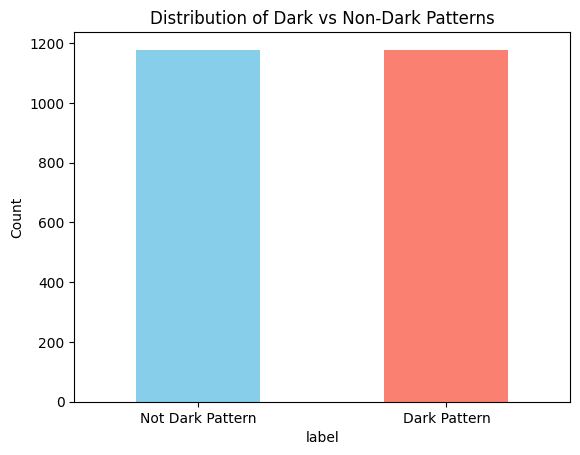

In [9]:
import matplotlib.pyplot as plt

# Count of dark vs non-dark patterns
df['label'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.xticks([0,1], ['Not Dark Pattern', 'Dark Pattern'], rotation=0)
plt.ylabel('Count')
plt.title('Distribution of Dark vs Non-Dark Patterns')
plt.show()


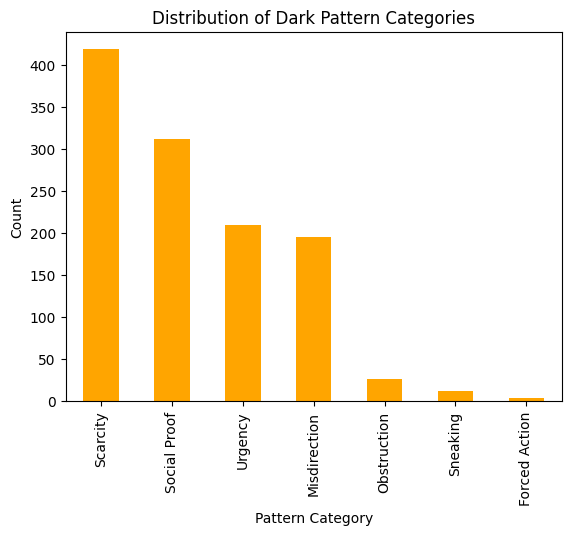

In [10]:
# Only dark patterns
dark_df = df[df['label']==1]

# Count per category
dark_df['Pattern Category'].value_counts().plot(kind='bar', color='orange')
plt.ylabel('Count')
plt.title('Distribution of Dark Pattern Categories')
plt.show()


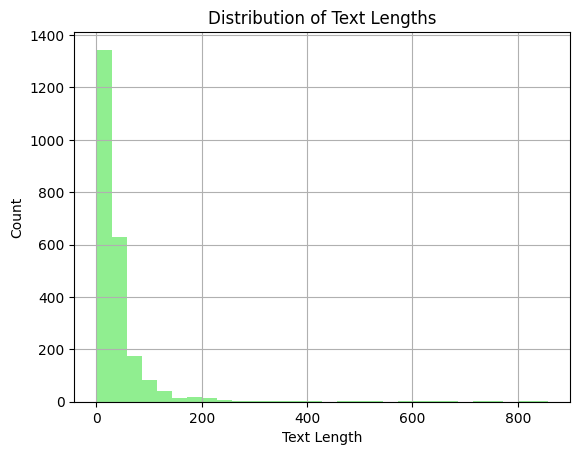

In [11]:
# Add a new column for text length
df['text_length'] = df['text'].apply(len)

# Plot histogram
df['text_length'].hist(bins=30, color='lightgreen')
plt.xlabel('Text Length')
plt.ylabel('Count')
plt.title('Distribution of Text Lengths')
plt.show()


In [12]:
pip install wordcloud


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Eakshitha\Desktop\darkpatterns\darkpatterns_env\Scripts\python.exe -m pip install --upgrade pip' command.


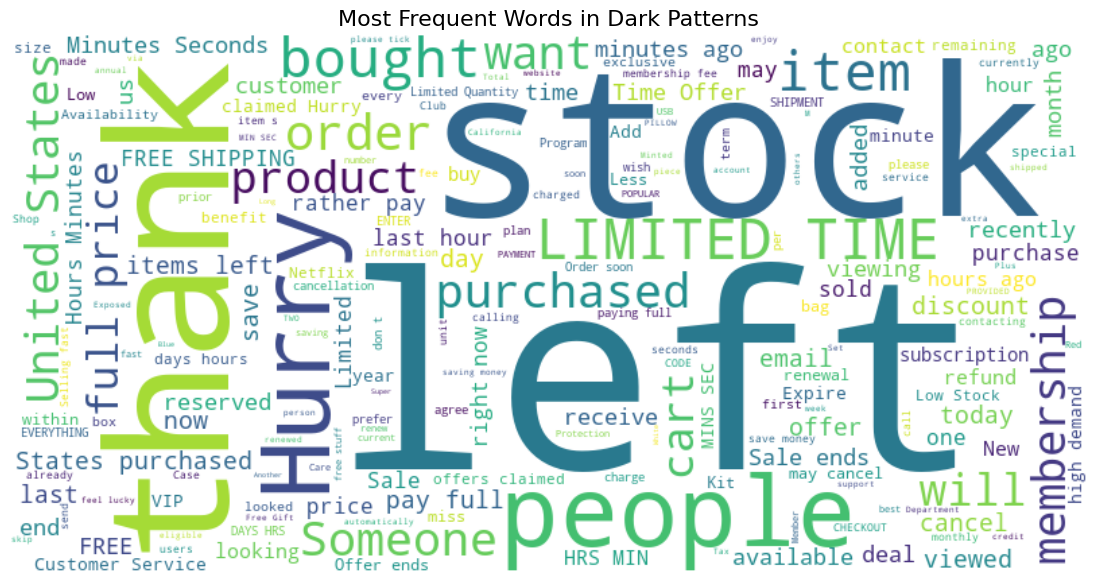

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all dark pattern texts
dark_text = " ".join(dark_df['text'].astype(str))

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(dark_text)

# Plot
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Dark Patterns", fontsize=16)
plt.show()


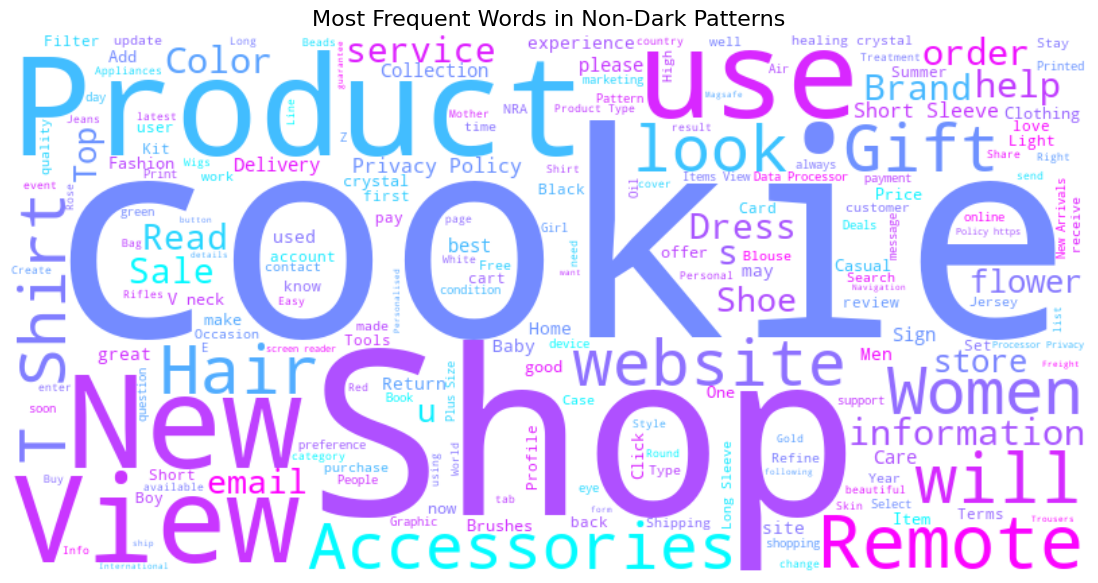

In [14]:
# Combine all non-dark pattern texts
non_dark_df = df[df['label']==0]
non_dark_text = " ".join(non_dark_df['text'].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='cool').generate(non_dark_text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Non-Dark Patterns", fontsize=16)
plt.show()


In [15]:
from collections import Counter
import re

# Function to get top N words
def get_top_words(text_series, N=20):
    words = " ".join(text_series.astype(str)).lower()
    words = re.findall(r'\b\w+\b', words)
    counter = Counter(words)
    return counter.most_common(N)

# Top 20 words in dark patterns
top_dark_words = get_top_words(dark_df['text'], 20)
print("Top 20 Dark Pattern Words:", top_dark_words)
from collections import Counter
import re

# Function to get top N words
def get_top_words(text_series, N=20):
    words = " ".join(text_series.astype(str)).lower()
    words = re.findall(r'\b\w+\b', words)
    counter = Counter(words)
    return counter.most_common(N)

# Top 20 words in dark patterns
top_dark_words = get_top_words(dark_df['text'], 20)
print("Top 20 Dark Pattern Words:", top_dark_words)


Top 20 Dark Pattern Words: [('in', 414), ('left', 342), ('only', 320), ('stock', 177), ('to', 173), ('this', 149), ('the', 146), ('i', 144), ('you', 142), ('your', 142), ('no', 138), ('1', 134), ('a', 121), ('time', 112), ('hurry', 106), ('limited', 102), ('thanks', 102), ('people', 98), ('for', 91), ('2', 89)]
Top 20 Dark Pattern Words: [('in', 414), ('left', 342), ('only', 320), ('stock', 177), ('to', 173), ('this', 149), ('the', 146), ('i', 144), ('you', 142), ('your', 142), ('no', 138), ('1', 134), ('a', 121), ('time', 112), ('hurry', 106), ('limited', 102), ('thanks', 102), ('people', 98), ('for', 91), ('2', 89)]


In [16]:
# Import libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load dataset
df = pd.read_csv("../dataset/dataset.csv")

# Optional: drop duplicates or missing
df = df.dropna().drop_duplicates()

# 2. Split data
X = df['text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Vectorize text
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 4. Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

# 5. Train & Evaluate
results = []

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    y_prob = model.predict_proba(X_test_vec)[:,1]  # For AUC

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, auc, f1, precision, recall])

# 6. Create DataFrame for results
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "AUC", "F1 Score", "Precision", "Recall"])
results_df


,Model,Accuracy,AUC,F1 Score,Precision,Recall
0,Logistic Regression,0.921610,0.974978,0.917960,0.928251,0.907895
1,SVM,0.930085,0.978178,0.928105,0.922078,0.934211
2,Random Forest,0.934322,0.980793,0.932166,0.930131,0.934211
3,Gradient Boosting,0.913136,0.955979,0.905747,0.951691,0.864035


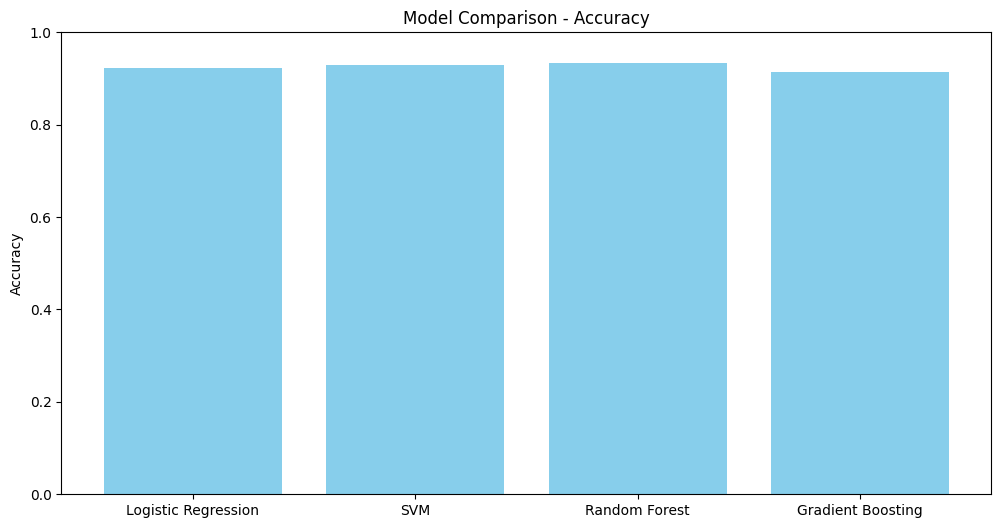

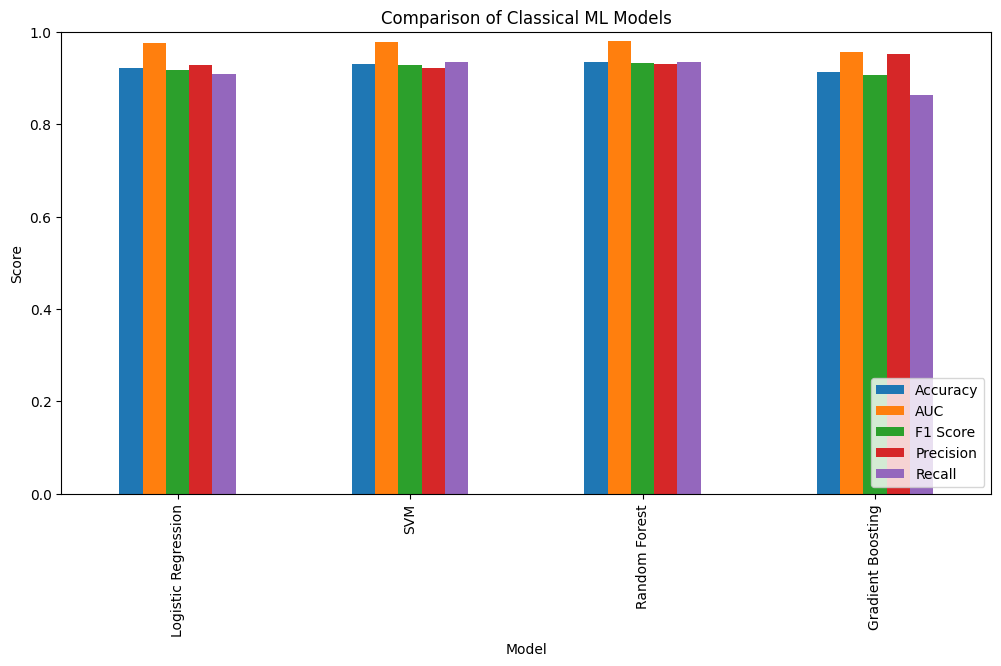

In [17]:
# Set figure size
plt.figure(figsize=(12,6))

# Plot Accuracy
plt.bar(results_df['Model'], results_df['Accuracy'], color='skyblue')
plt.ylim(0,1)
plt.ylabel('Accuracy')
plt.title('Model Comparison - Accuracy')
plt.show()

# Optional: Plot other metrics together
metrics = ['Accuracy', 'AUC', 'F1 Score', 'Precision', 'Recall']
results_df.set_index('Model')[metrics].plot(kind='bar', figsize=(12,6))
plt.ylim(0,1)
plt.ylabel('Score')
plt.title('Comparison of Classical ML Models')
plt.legend(loc='lower right')
plt.show()


In [18]:
# results_df contains metrics for all models
best_model_row = results_df.loc[results_df['F1 Score'].idxmax()]
best_model_name = best_model_row['Model']

print("Best model based on F1 Score:", best_model_name)
print(best_model_row)


Best model based on F1 Score: Random Forest
Model        Random Forest
Accuracy          0.934322
AUC               0.980793
F1 Score          0.932166
Precision         0.930131
Recall            0.934211
Name: 2, dtype: object


In [19]:
import joblib

# Get the actual model object from our models dictionary
best_model = models[best_model_name]

# Save model and vectorizer
joblib.dump(best_model, "../classical_model/best_model.pkl")
joblib.dump(vectorizer, "../classical_model/vectorizer.pkl")

print(f"{best_model_name} saved as the best model based on F1 Score!")


Random Forest saved as the best model based on F1 Score!


In [20]:
# Load model
model = joblib.load("../classical_model/best_model.pkl")
vectorizer = joblib.load("../classical_model/vectorizer.pkl")

# Sample text prediction
sample_text = ["FLASH SALE | LIMITED TIME ONLY Shop Now"]
sample_vec = vectorizer.transform(sample_text)
prediction = model.predict(sample_vec)
print("Prediction (1=Dark, 0=Not Dark):", prediction[0])


Prediction (1=Dark, 0=Not Dark): 1


In [23]:
import joblib

# Load model
model = joblib.load("best_model.pkl")
vectorizer = joblib.load("vectorizer.pkl")

# Example text
texts = ["FLASH SALE | LIMITED TIME ONLY Shop Now", "Write a review"]
X_vec = vectorizer.transform(texts)
preds = model.predict(X_vec)
print(preds)  # 1 = Dark Pattern, 0 = Not Dark Pattern


[1 0]
